In [2]:
##### SI Figures 3 and 4: relationships between capital and labor intensities 

from pathlib import Path
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from matplotlib.colors import to_hex
import matplotlib.colors as mcolors

In [3]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# pixel intensities (needed for LMH raster classification, figure 2)
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# sub-national intensities 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# country intensities
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [4]:
##### Data prep

# align CRS
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
capital_intensity = capital_intensity.rio.reproject(target_crs)

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

sub_national_capital_geo = sub_national_capital_geo.to_crs(capital_intensity.rio.crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(capital_intensity.rio.crs)
country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

crs = capital_intensity.rio.crs

# merge sub-national data
sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')
sub_national = sub_national_capital.merge(sub_national_labor, on=['PROJ_ID', 'ISO3', 'geometry'], how='inner')
sub_national = sub_national.merge(country_codes, on='ISO3', how='left') # add income group data

# merge country-level data
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

# identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)
country_boundaries['has_capital_and_labor_data'] = (
    (country_boundaries['has_capital_data'] == 1) &
    (country_boundaries['has_labor_data'] == 1)
).astype(int)

# convert intensities to log1p (country + sub-national scale only)

sub_national['capital_intensity_USD_per_million_tonne'] = sub_national['capital_intensity_USD_per_tonne'] * 1e6
country_boundaries['capital_intensity_USD_per_million_tonne'] = country_boundaries['capital_intensity_USD_per_tonne'] * 1e6

sub_national['labor_intensity_jobs_per_million_tonne'] = sub_national['labor_intensity_jobs_per_tonne'] * 1e6
country_boundaries['labor_intensity_jobs_per_million_tonne'] = country_boundaries['labor_intensity_jobs_per_tonne'] * 1e6

sub_national['log1p_capital_intensity_USD_per_million_tonne'] = np.log1p(sub_national['capital_intensity_USD_per_million_tonne'])
country_boundaries['log1p_capital_intensity_USD_per_million_tonne'] = np.log1p(country_boundaries['capital_intensity_USD_per_million_tonne'])

sub_national['log1p_labor_intensity_jobs_per_million_tonne'] = np.log1p(sub_national['labor_intensity_jobs_per_million_tonne'])
country_boundaries['log1p_labor_intensity_jobs_per_million_tonne'] = np.log1p(country_boundaries['labor_intensity_jobs_per_million_tonne'])

# prep income group data (country + sub-national scale only)

country_valid = country_boundaries[
    country_boundaries['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    country_boundaries['log1p_labor_intensity_jobs_per_million_tonne'].notna() &
    country_boundaries['income_gro'].notna() 
]

x_country = country_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_country = country_valid['log1p_labor_intensity_jobs_per_million_tonne'].values
income_country = country_valid['income_gro'].values

lr_country = stats.linregress(x_country, y_country)

sub_valid = sub_national[
    sub_national['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    sub_national['log1p_labor_intensity_jobs_per_million_tonne'].notna() &
    sub_national['income_group'].notna() 
]

x_sub = sub_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_sub = sub_valid['log1p_labor_intensity_jobs_per_million_tonne'].values
income_sub = sub_valid['income_group'].values

lr_sub = stats.linregress(x_sub, y_sub)


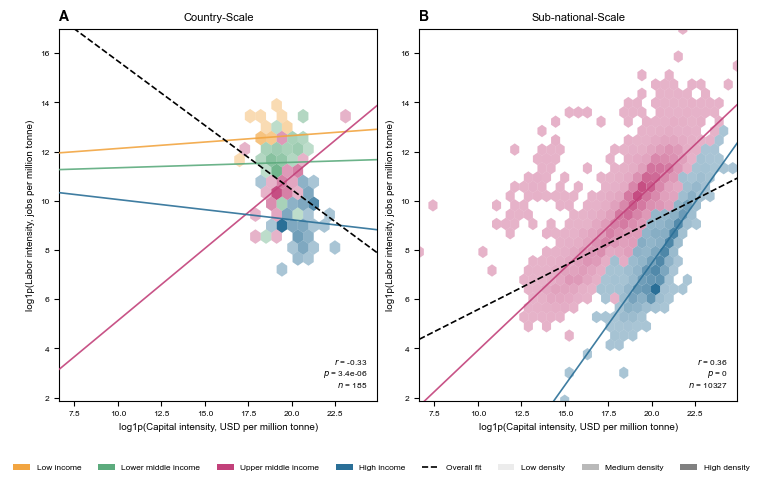

In [11]:
##### SI FIGURE 3: Side-by-side hexbin plots, colored by dominant income group, alpha by density

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
})

### Create color map of income groups
income_colors = {
    "Low income": "#F2A541",
    "Lower middle income": "#5CAB7D",
    "Upper middle income": "#C2417A",
    "High income": "#2A6F97",
}
group_list = list(income_colors.keys())
group_to_code = {g: i for i, g in enumerate(group_list)}

def mode_reduce_factory(n_groups):
    def mode_reduce(codes):
        codes = np.asarray(codes, dtype=int)
        counts = np.bincount(codes, minlength=n_groups)
        return counts.argmax()
    return mode_reduce

# define plotting function
def plot_hexbin(ax, x, y, groups, lr, panel_letter, title, xlabel, ylabel, xlim, ylim,
                 income_colors, gridsize=45, min_group_n=3,
                 min_alpha=0.4, max_alpha=1.0):
    x_line_full = np.linspace(xlim[0], xlim[1], 100)

    # map groups to integer codes, dropping any unmapped/NaN groups
    codes = np.array([group_to_code.get(g, -1) for g in groups])
    keep = codes >= 0
    x_hex, y_hex, codes = x[keep], y[keep], codes[keep]

    mode_reduce = mode_reduce_factory(len(group_list))

    # hexbin colored by dominant income group per hex
    hb_mode = ax.hexbin(
        x_hex, y_hex, C=codes, gridsize=gridsize, extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        reduce_C_function=mode_reduce, mincnt=1
    )
    dominant_codes = hb_mode.get_array().astype(int)

    # separate hexbin (same grid/extent) purely to get per-hex point counts for density
    hb_count = ax.hexbin(
        x_hex, y_hex, gridsize=gridsize, extent=(xlim[0], xlim[1], ylim[0], ylim[1]), mincnt=1
    )
    counts = hb_count.get_array()
    hb_count.remove()  # only needed it for the counts

    # normalize density independently for this axes
    if counts.max() > counts.min():
        norm_counts = (counts - counts.min()) / (counts.max() - counts.min())
    else:
        norm_counts = np.ones_like(counts)
    alphas = min_alpha + norm_counts * (max_alpha - min_alpha)

    # build RGBA face colors: color = dominant income group, alpha = density
    rgba = np.array([mcolors.to_rgba(income_colors[group_list[c]]) for c in dominant_codes])
    rgba[:, 3] = alphas

    hb_mode.set_array(None)  # disable cmap-based mapping so facecolors take over
    hb_mode.set_facecolor(rgba)
    hb_mode.set_edgecolor("none")

    # income-group-specific line of best fit
    for group, color in income_colors.items():
        mask = groups == group
        n_group = mask.sum()
        if n_group >= min_group_n:
            lr_group = stats.linregress(x[mask], y[mask])
            y_line_group = lr_group.intercept + lr_group.slope * x_line_full
            ax.plot(x_line_full, y_line_group, color=color, linewidth=1.2, linestyle="-", alpha=0.9, zorder=5)

    # overall line of best fit
    y_line = lr.intercept + lr.slope * x_line_full
    ax.plot(x_line_full, y_line, color="black", linewidth=1.2, linestyle="--", label="Overall fit", zorder=6)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Panel letter (left) + descriptive sub-title (center), as real axes
    # titles so they're layout-aware and can't overlap
    ax.set_title(panel_letter, loc="left", fontsize=10, fontweight="bold")
    ax.set_title(title, loc="center", fontsize=8)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)

    ax.text(
        0.97, 0.03,
        f"$r$ = {lr.rvalue:.2f}\n$p$ = {lr.pvalue:.2g}\n$n$ = {len(x)}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=6,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

# shared axis limits across both panels
x_hi = max(x_country.max(), x_sub.max())
x_lo = min(x_country.min(), x_sub.min())
y_hi = max(y_country.max(), y_sub.max())
y_lo = min(y_country.min(), y_sub.min())

xlim = (x_lo, x_hi)
ylim = (y_lo, y_hi)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.3), layout="constrained")
# Main title removed — belongs in the caption. Panel sub-titles kept.

plot_hexbin(
    axes[0], x_country, y_country, income_country, lr_country,
    panel_letter="A", title="Country-Scale",
    xlabel="log1p(Capital intensity, USD per million tonne)",
    ylabel="log1p(Labor intensity, jobs per million tonne)",
    xlim=xlim, ylim=ylim, income_colors=income_colors, gridsize=30
)

plot_hexbin(
    axes[1], x_sub, y_sub, income_sub, lr_sub,
    panel_letter="B", title="Sub-national-Scale",
    xlabel="log1p(Capital intensity, USD per million tonne)",
    ylabel="log1p(Labor intensity, jobs per million tonne)",
    xlim=xlim, ylim=ylim, income_colors=income_colors, gridsize=35
)

# --- Build legend manually ---
income_handles = [
    mpatches.Patch(facecolor=color, edgecolor="none", label=group)
    for group, color in income_colors.items()
]
fit_line_handle = plt.Line2D([0], [0], color="black", linewidth=1.2, linestyle="--", label="Overall fit")

# density/alpha legend entries (using a neutral gray to show transparency scale)
density_handles = [
    mpatches.Patch(facecolor="gray", edgecolor="none", alpha=0.15, label="Low density"),
    mpatches.Patch(facecolor="gray", edgecolor="none", alpha=0.55, label="Medium density"),
    mpatches.Patch(facecolor="gray", edgecolor="none", alpha=1.0, label="High density"),
]

legend = fig.legend(
    handles=income_handles + [fit_line_handle] + density_handles,
    loc="lower center", ncol=len(income_colors) + 1 + len(density_handles),
    bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=6
)

fig.savefig(
    f"{fd}/SI_fig_3_intensity_hexbins.tiff",
    dpi=300, format="tiff",
    bbox_inches="tight",
    bbox_extra_artists=[legend]
)

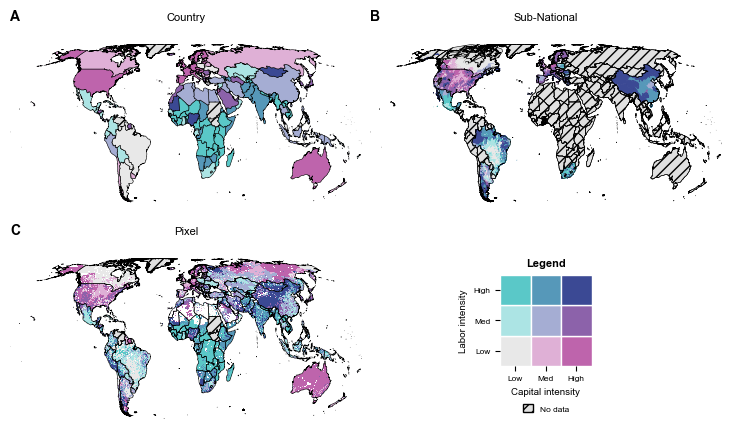

In [14]:
#### SI Figure 4: Map L/M/H intensity classifications


# Classify regions into L/M/H

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
})


def classify_lmh(raster, thresholds=(1/3, 2/3)):
    vals = raster.squeeze().values
    valid = np.isfinite(vals)

    low_cut, high_cut = np.nanquantile(vals[valid], thresholds)

    classed = np.full(vals.shape, np.nan)
    classed[valid & (vals <= low_cut)] = 0                      # Low
    classed[valid & (vals > low_cut) & (vals <= high_cut)] = 1  # Medium
    classed[valid & (vals > high_cut)] = 2                       # High

    return classed, (low_cut, high_cut)


capital_class, capital_cuts = classify_lmh(capital_intensity)
labor_class, labor_cuts = classify_lmh(labor_intensity)

# combine into single 0-8 class code: class_id = capital_class * 3 + labor_class
combined_valid = np.isfinite(capital_class) & np.isfinite(labor_class)
class_id = np.full(capital_class.shape, np.nan)
class_id[combined_valid] = capital_class[combined_valid] * 3 + labor_class[combined_valid]

# build classified raster, matching capital_intensity's grid/coords
classified_raster = capital_intensity.squeeze().copy(data=class_id)
classified_raster = classified_raster.rio.write_nodata(np.nan)
classified_raster = classified_raster.rio.write_crs(crs)

#### Classify country and sub-national data into terciles

# define function to classify L/M/H terciles
def classify_lmh_from_values(values, thresholds=(1/3, 2/3)):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    low_cut, high_cut = np.nanquantile(values[valid], thresholds)

    classed = np.full(values.shape, np.nan)
    classed[valid & (values <= low_cut)] = 0
    classed[valid & (values > low_cut) & (values <= high_cut)] = 1
    classed[valid & (values > high_cut)] = 2

    return classed, (low_cut, high_cut)

# classify countries using their own distribution's terciles
country_boundaries['capital_class'], country_capital_cuts = classify_lmh_from_values(
    country_boundaries['capital_intensity_USD_per_tonne']
)
country_boundaries['labor_class'], country_labor_cuts = classify_lmh_from_values(
    country_boundaries['labor_intensity_jobs_per_tonne']
)

# classify sub-national using their own distribution's terciles
sub_national['capital_class'], sub_capital_cuts = classify_lmh_from_values(
    sub_national['capital_intensity_USD_per_tonne']
)
sub_national['labor_class'], sub_labor_cuts = classify_lmh_from_values(
    sub_national['labor_intensity_jobs_per_tonne']
)

##### Plot figure 

# filter valid country/sub-national data
country_combined_valid = country_boundaries['capital_class'].notna() & country_boundaries['labor_class'].notna()
country_boundaries['class_id'] = np.nan
country_boundaries.loc[country_combined_valid, 'class_id'] = (
    country_boundaries.loc[country_combined_valid, 'capital_class'] * 3
    + country_boundaries.loc[country_combined_valid, 'labor_class']
)

sub_combined_valid = sub_national['capital_class'].notna() & sub_national['labor_class'].notna()
sub_national['class_id'] = np.nan
sub_national.loc[sub_combined_valid, 'class_id'] = (
    sub_national.loc[sub_combined_valid, 'capital_class'] * 3
    + sub_national.loc[sub_combined_valid, 'labor_class']
)

# bivariate color scheme: rows = labor class (0=L,1=M,2=H), cols = capital class (0=L,1=M,2=H)
# shared across both panels — same colors mean same L/M/H class in each panel's own distribution
bivariate_colors = {
    (0, 0): '#e8e8e8', (1, 0): '#ace4e4', (2, 0): '#5ac8c8',   # capital = Low
    (0, 1): '#dfb0d6', (1, 1): '#a5add3', (2, 1): '#5698b9',   # capital = Medium
    (0, 2): '#be64ac', (1, 2): '#8c62aa', (2, 2): '#3b4994',   # capital = High
}

# key = (labor_class, capital_class)
cmap_list = [bivariate_colors[(lab, cap)] for cap in range(3) for lab in range(3)]

# ordered to match class_id = capital_class * 3 + labor_class
bivariate_cmap = plt.matplotlib.colors.ListedColormap(cmap_list)
bounds = np.arange(-0.5, 9.5, 1)
norm = plt.matplotlib.colors.BoundaryNorm(bounds, bivariate_cmap.N)

missing_color = "#e0e0e0"  # lighter grey, matches other maps
missing_hatch = "///"

# --- Compute figure height from actual data aspect ratio, sized to
# double-column print width so specified point sizes are what prints ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
data_width = maxx - minx
data_height = maxy - miny
data_aspect = data_height / data_width

fig_width = 7.2
# 2x2 grid: two columns of roughly equal width for the panels
panel_width = fig_width / 2
panel_height = panel_width * data_aspect
fig_height = 2 * panel_height + 1.0  # room for panel titles across both rows

fig = plt.figure(figsize=(fig_width, fig_height), layout="constrained")
gs = fig.add_gridspec(2, 2)
# Main title removed — belongs in the caption. Panel titles kept.

# --- Panel A: country choropleth (own-distribution terciles) — top left ---
ax_country = fig.add_subplot(gs[0, 0])

country_has_data = country_boundaries[country_boundaries['has_capital_and_labor_data'] == 1]
country_no_data = country_boundaries[country_boundaries['has_capital_and_labor_data'] == 0]

country_no_data.plot(ax=ax_country, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch=missing_hatch, zorder=1)
country_has_data.plot(
    ax=ax_country, column="class_id", cmap=bivariate_cmap, norm=norm,
    edgecolor="black", linewidth=0.4, zorder=2
)

ax_country.set_xlim(minx, maxx)
ax_country.set_ylim(miny, maxy)
ax_country.set_axis_off()
ax_country.set_title("A", loc="left", fontsize=10, fontweight="bold")
ax_country.set_title("Country", loc="center", fontsize=8)

# --- Panel B: sub-national choropleth (own-distribution terciles) — top right ---
ax_sub = fig.add_subplot(gs[0, 1])

sub_has_data = sub_national[sub_national['class_id'].notna()]
sub_no_data = sub_national[sub_national['class_id'].isna()]

country_boundaries.plot(ax=ax_sub, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch=missing_hatch, zorder=1)

sub_no_data.plot(ax=ax_sub, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch=missing_hatch, zorder=1)

colors = [to_hex(bivariate_cmap(norm(v))) for v in sub_has_data["class_id"]]

sub_has_data.plot(
    ax=ax_sub,
    color=colors,
    edgecolor=colors,
    linewidth=0.4,
    zorder=2,
)

country_boundaries.plot(ax=ax_sub, facecolor="none", edgecolor="black", linewidth=0.4, zorder=3)

ax_sub.set_xlim(minx, maxx)
ax_sub.set_ylim(miny, maxy)
ax_sub.set_axis_off()
ax_sub.set_title("B", loc="left", fontsize=10, fontweight="bold")
ax_sub.set_title("Sub-National", loc="center", fontsize=8)

# --- Panel C: pixel raster classification (own-distribution terciles) — bottom left ---
ax_map = fig.add_subplot(gs[1, 0])

country_boundaries[country_boundaries['has_capital_and_labor_data'] == 0].plot(
    ax=ax_map, facecolor=missing_color, edgecolor="black", linewidth=0.4, hatch=missing_hatch, zorder=1
)

classified_raster.plot(
    ax=ax_map, cmap=bivariate_cmap, norm=norm,
    add_colorbar=False, add_labels=False, zorder=2
)

country_boundaries.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=0.4, zorder=3)

ax_map.set_xlim(minx, maxx)
ax_map.set_ylim(miny, maxy)
ax_map.set_axis_off()
ax_map.set_title("C", loc="left", fontsize=10, fontweight="bold")
ax_map.set_title("Pixel", loc="center", fontsize=8)

# --- 3x3 grid legend panel — bottom right ---
ax_legend = fig.add_subplot(gs[1, 1])
ax_legend.axis("off")

# Grid drawn in its own small inset, centered in the legend panel since
# this panel is now the same size/shape as a map panel rather than a
# narrow column
grid_ax = ax_legend.inset_axes([0.25, 0.35, 0.5, 0.5])
grid_ax.set_aspect("equal")

labels_lmh = ["Low", "Med", "High"]

for cap in range(3):       # x-axis: capital class
    for lab in range(3):   # y-axis: labor class
        grid_ax.add_patch(
            mpatches.Rectangle((cap, lab), 1, 1, facecolor=bivariate_colors[(lab, cap)], edgecolor="white")
        )

grid_ax.set_xlim(0, 3)
grid_ax.set_ylim(0, 3)
grid_ax.set_xticks([0.5, 1.5, 2.5])
grid_ax.set_xticklabels(labels_lmh, fontsize=6)
grid_ax.set_yticks([0.5, 1.5, 2.5])
grid_ax.set_yticklabels(labels_lmh, fontsize=6)
grid_ax.set_xlabel("Capital intensity", fontsize=7)
grid_ax.set_ylabel("Labor intensity", fontsize=7)
grid_ax.set_title("Legend", fontsize=8, fontweight="bold")
for spine in grid_ax.spines.values():
    spine.set_visible(False)

# "No data" swatch placed below the inset grid, in its own reserved
# space within the legend panel
missing_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black", hatch=missing_hatch, label="No data")
ax_legend.legend(
    handles=[missing_patch], loc="center", bbox_to_anchor=(0.5, 0.12),
    frameon=False, fontsize=6, handlelength=1.2, handleheight=1.2
)

fig.savefig(f"{fd}/SI_fig_4_intensity_class_map.tiff", dpi=300, format="tiff")
plt.show()